## Big Picture
"Which videos outperform expectation, why, and under what statistical structure?”


Regression Summary:
                            OLS Regression Results                            
Dep. Variable:              log_views   R-squared:                       0.589
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                 4.467e+06
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:04:29   Log-Likelihood:            -1.0970e+07
No. Observations:             6242453   AIC:                         2.194e+07
Df Residuals:                 6242450   BIC:                         2.194e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7783      0.00

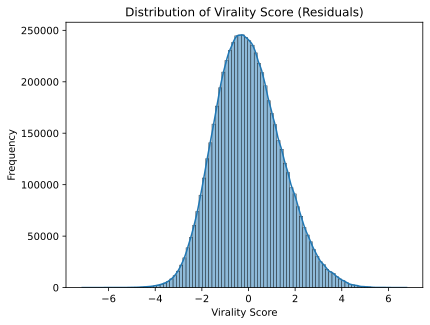

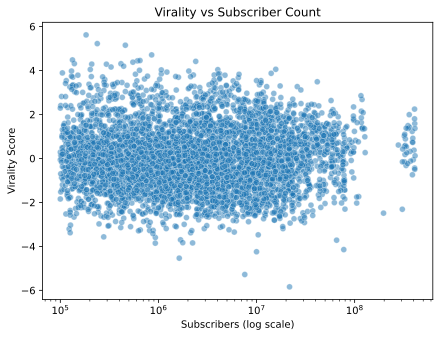

In [1]:
#Module 1 
#Virality model defined as deviation from log linear regression of views, regressors being channel size and time  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

%config InlineBackend.figure_format = 'svg'

df = pd.read_parquet(r"C:\Users\vkeer\Downloads\yt_cleaned .parquet")

# Parse ISO duration (PT#H#M#S)
def parse_duration(s):
    import re
    if pd.isna(s):
        return np.nan
    hours   = int(m.group(1)) if (m := re.search(r'(\d+)H', s)) else 0
    minutes = int(m.group(1)) if (m := re.search(r'(\d+)M', s)) else 0
    seconds = int(m.group(1)) if (m := re.search(r'(\d+)S', s)) else 0
    return hours * 3600 + minutes * 60 + seconds

df['duration_sec'] = df['video_duration'].apply(parse_duration)
df['duration_min'] = df['duration_sec'] / 60

# Convert numeric fields
df['view_count']       = pd.to_numeric(df['video_view_count'], errors='coerce')
df['like_count']       = pd.to_numeric(df['video_like_count'], errors='coerce')
df['comment_count']    = pd.to_numeric(df['video_comment_count'], errors='coerce')
df['subscriber_count'] = pd.to_numeric(df['channel_subscriber_count'], errors='coerce')

# Convert datetime
df['published_at']  = pd.to_datetime(df['video_published_at'], utc=True, errors='coerce')
df['trending_date'] = pd.to_datetime(df['video_trending__date'], utc=True, errors='coerce')

# Engagement rates
df['like_rate']    = df['like_count'] / df['view_count']
df['comment_rate'] = df['comment_count'] / df['view_count']

# Remove Movies (no views)
df = df[df['video_category_id'] != 'Movies']

# Remove long videos (>60 min)
df_clean = df[df['duration_min'] <= 60].copy()

# Remove invalid rows
df_clean = df_clean.dropna(subset=[
    'view_count', 'subscriber_count',
    'published_at', 'trending_date'
])


df_clean['days_since_upload'] = (
    (df_clean['trending_date'] - df_clean['published_at'])
    .dt.days.clip(lower=1)
)

# LOG TRANSFORMATION

df_clean['log_views'] = np.log1p(df_clean['view_count'])
df_clean['log_subs']  = np.log1p(df_clean['subscriber_count'])
df_clean['log_days']  = np.log1p(df_clean['days_since_upload'])


# REGRESSION MODEL (EXPECTED PERFORMANCE)

X = df_clean[['log_subs', 'log_days']]
X = sm.add_constant(X)  # adds intercept β0
y = df_clean['log_views']

model = sm.OLS(y, X).fit()

print("\nRegression Summary:")
print(model.summary())

# VIRALITY SCORE (RESIDUAL)

df_clean['virality_score'] = model.resid

# Define viral (top 10%)
viral_threshold = df_clean['virality_score'].quantile(0.90)
df_clean['viral'] = (df_clean['virality_score'] >= viral_threshold).astype(int)

# ADDITIONAL FEATURES
df_clean['views_per_sub'] = df_clean['view_count'] / df_clean['subscriber_count']
df_clean['views_per_day'] = df_clean['view_count'] / df_clean['days_since_upload']

# DESCRIPTIVE STATISTICS

numeric_cols = [
    'view_count', 'like_count', 'comment_count',
    'subscriber_count', 'duration_min',
    'like_rate', 'comment_rate',
    'virality_score'
]

summary = df_clean[numeric_cols].describe().T
summary['skew']   = df_clean[numeric_cols].skew()
summary['median'] = df_clean[numeric_cols].median()

print("\nSummary Statistics:")
print(summary[['count', 'mean', 'median', 'std', 'min', 'max', 'skew']].round(2).to_string())

# VIRALITY OVERVIEW

print("\nVirality Distribution:")
print(df_clean['virality_score'].describe())

print("\nViral vs Non-Viral Count:")
print(df_clean['viral'].value_counts())


# VISUALISATIONS
# Virality distribution
plt.figure()
sns.histplot(df_clean['virality_score'], bins=100, kde=True)
plt.title("Distribution of Virality Score (Residuals)")
plt.xlabel("Virality Score")
plt.ylabel("Frequency")
plt.show()

# Residual diagnostics
plt.figure()
sns.scatterplot(x=model.fittedvalues, y=model.resid, alpha=0.3)
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted log(Views)")
plt.ylabel("Residuals")
plt.show()

# Virality vs subscribers
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='subscriber_count',
    y='virality_score',
    data=df_clean.sample(5000),
    alpha=0.5
)
plt.xscale('log')
plt.title("Virality vs Subscriber Count")
plt.xlabel("Subscribers (log scale)")
plt.ylabel("Virality Score")
plt.show()

### Interpretation 



Category Statistics:
                       video_count  median_views    mean_views  median_likes  \
video_category_id                                                              
Nonprofits & Activism           12     1503839.5  2.145916e+06       58677.5   
Howto & Style               102646     7898084.5  2.551182e+07      120790.0   
Pets & Animals               23403     6030651.0  2.863288e+07      153284.0   
People & Blogs              739831     3294069.0  1.869403e+07      102145.0   
Sports                      388727     2556869.0  1.130176e+07       51313.0   
Comedy                      232851     5740553.0  1.706570e+07      196042.0   
Film & Animation            181365     2002277.0  6.881935e+06       72162.0   
Travel & Events              26799     1311037.0  1.539619e+07       55919.0   
Science & Technology         59998     4212960.5  1.883860e+07      146600.0   
Education                    52548     1903172.0  6.487099e+06       66711.0   
Entertainment     

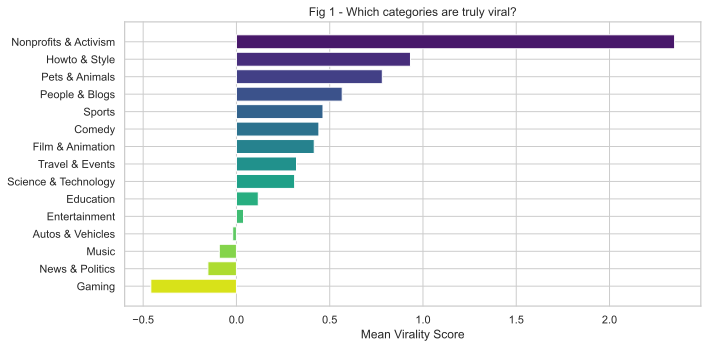

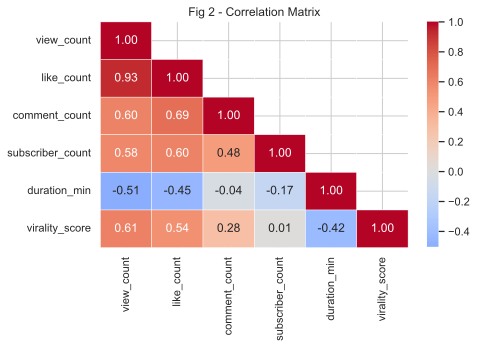

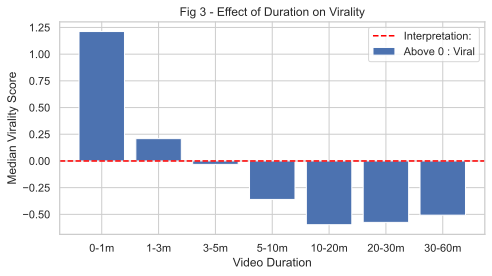

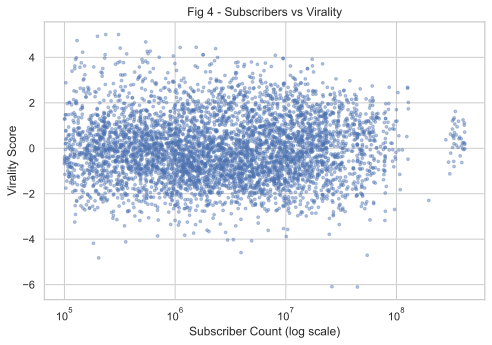

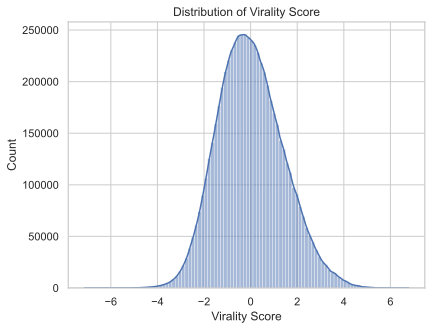

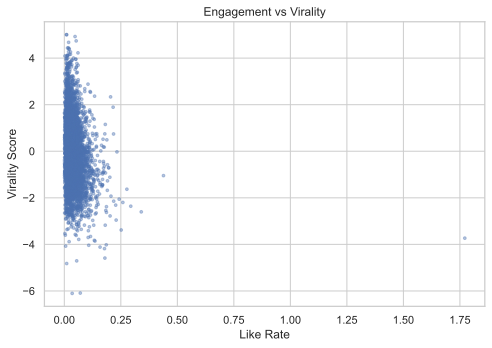

In [2]:
#Categorical Effects

cat_stats = (
    df_clean.groupby("video_category_id")
    .agg(
        video_count=("view_count", "count"),
        median_views=("view_count", "median"),
        mean_views=("view_count", "mean"),
        median_likes=("like_count", "median"),
        median_duration=("duration_min", "median"),
        viral_rate=("viral", "mean"),
        mean_virality=("virality_score", "mean"),
    )
    .sort_values("mean_virality", ascending=False)
    .round(3)
)

print("\nCategory Statistics:")
print(cat_stats)

sns.set_theme(style="whitegrid")

# Fig 1 - Virality by category
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(cat_stats.index, cat_stats["mean_virality"],
        color=sns.color_palette("viridis", len(cat_stats)))
ax.set_xlabel("Mean Virality Score")
ax.set_title("Fig 1 - Which categories are truly viral?")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Fig 2 - Correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))

corr_cols = [
    "view_count", "like_count", "comment_count",
    "subscriber_count", "duration_min", "virality_score"
]
corr = df_clean[corr_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.4, ax=ax
)
ax.set_title("Fig 2 - Correlation Matrix")
plt.tight_layout()
plt.show()

# Fig 3 - Duration vs virality
df_clean["duration_bin"] = pd.cut(
    df_clean["duration_min"],
    bins=[0, 1, 3, 5, 10, 20, 30, 60],
    labels=["0-1m", "1-3m", "3-5m", "5-10m", "10-20m", "20-30m", "30-60m"],
)

fig, ax = plt.subplots(figsize=(7, 4))
dur_virality = df_clean.groupby("duration_bin", observed=True)["virality_score"].median()

ax.bar(dur_virality.index.astype(str), dur_virality.values)
ax.set_xlabel("Video Duration")
ax.set_ylabel("Median Virality Score")
ax.axhline(0, color='red', linestyle='--')
ax.set_title("Fig 3 - Effect of Duration on Virality")
ax.legend(["Interpretation:","Above 0 : Viral","Below 0 : Underperforming"])
plt.tight_layout()
plt.show()

# Fig 4 - Subscribers vs virality
fig, ax = plt.subplots(figsize=(7, 5))

sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)

ax.scatter(
    sample["subscriber_count"],
    sample["virality_score"],
    alpha=0.4,
    s=8
)

ax.set_xscale("log")
ax.set_xlabel("Subscriber Count (log scale)")
ax.set_ylabel("Virality Score")
ax.set_title("Fig 4 - Subscribers vs Virality")
plt.tight_layout()
plt.show()

# Fig 5 - Virality distribution
plt.figure()
sns.histplot(df_clean['virality_score'], bins=100, kde=True)
plt.title("Distribution of Virality Score")
plt.xlabel("Virality Score")
plt.show()

# Fig 6 - Engagement vs virality
fig, ax = plt.subplots(figsize=(7, 5))

sample = df_clean.sample(5000, random_state=42)

ax.scatter(
    sample["like_rate"],
    sample["virality_score"],
    alpha=0.4,
    s=8
)

ax.set_xlabel("Like Rate")
ax.set_ylabel("Virality Score")
ax.set_title("Engagement vs Virality")
plt.tight_layout()
plt.show()

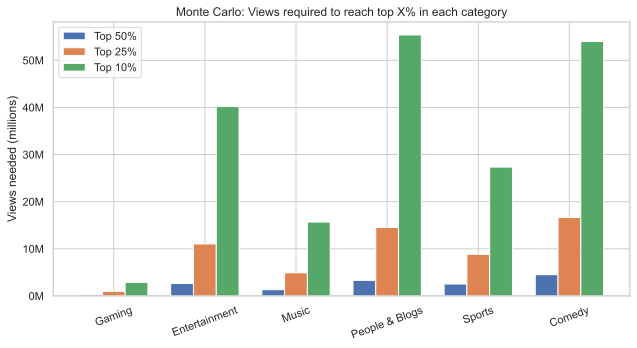

In [3]:
#Monte Carlo Method : simulating view distributions per category
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# Top categories (by volume)
top_cats = (
    df_clean["video_category_id"]
    .value_counts()
    .head(6)
    .index
)

target_percentiles = [50, 75, 90]
sim_thresholds = {}

for cat in top_cats:
    views = df_clean.loc[
        df_clean["video_category_id"] == cat, "view_count"
    ].dropna().values
    
    lv = np.log(views[views > 0])
    
    sim = np.random.lognormal(
        mean=lv.mean(),
        sigma=lv.std(),
        size=50_000
    )
    
    sim_thresholds[cat] = {
        f"Top {100-p}%": np.percentile(sim, p) / 1e6
        for p in target_percentiles
    }

thresh_df = pd.DataFrame(sim_thresholds).T

# Plot
x = np.arange(len(top_cats))
width = 0.25

fig, ax = plt.subplots(figsize=(9,5))
for i, col in enumerate(thresh_df.columns):
    ax.bar(x + i*width, thresh_df[col], width, label=col)

ax.set_xticks(x + width)
ax.set_xticklabels(thresh_df.index, rotation=20)
ax.set_ylabel("Views needed (millions)")
ax.set_title("Monte Carlo: Views required to reach top X% in each category")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
ax.legend()
plt.tight_layout()
plt.show()

### QQ Plot